In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Exercise 7 - Inverted Pendulum and Metastable Equilibrium

Consider an ideal inverted pendulum mounted on a cart on which an external force acts.

* The inverted pendulum is attached at one end to the center of mass of the cart, which has a mass $M$.  
  Rotation around this fixed point is assumed to be frictionless.

* The other end of the pendulum has a mass $m$, while the rigid rod connecting it to the cart is assumed massless and has length $l$.

* The angular displacement of the pendulum with respect to the vertical axis is denoted as $\theta$.

* The cart can only move along the surface, i.e., only in the $x$ direction.

* The pendulum is only subject to the gravitational force $\vec G$ in the negative $y$ direction.

* Let the coordinates of the cart's center of mass be $x$ and $y=0$, and those of the pendulum mass be $x_p$ and $y_p$, which can be expressed as a function of the cart's position and the angle $\theta$ relative to the vertical.

* The cart is subject to an external force $\vec u$ in the $x$ direction and a frictional force $\vec F$, also in the $x$ direction, given by $-\mu \dot x$, where $\dot x$ is the velocity of the cart and $\mu$ is the coefficient of friction between the cart and the surface.

The equations of motion of the system are given by:

\begin{align}
\ddot{x} =& \lambda(\theta)\left[m\,g\,l^2\,\dot{\theta}^2\sin\theta - m\,g\,l\,\sin\theta\,\cos\theta - l\mu \dot{x} + u\,l \right],\nonumber\\
 \ddot{\theta} =& \lambda(\theta)\left[\left(m + M\right)\,g\,\sin\theta - m\,g\,l\,\dot{\theta}^2\,\sin\theta \cos\theta +  \mu\dot{x}\cos\theta - u\cos\theta \right],\nonumber
\end{align}

with

$$\lambda(\theta) = \frac{1}{l\,(M + m\sin^2\theta)}.$$

We first study the system evolution starting from the initial conditions $x(0)=\dot x(0)=\theta(0)=\dot\theta(0)=0$.

1. Using the values $M=1$ kg, $m=0.1$ kg, $l=0.2$ m, $g=9.81$ m/s$^2$, $\mu=10$ kg/s, solve and plot the evolution of the system (coordinates $x$ and $\theta$) over 10 s when the external applied force is zero, $u=0$.  

    Explain why the chosen method is appropriate for solving the system of equations and the temporal spacing used.  
    What is the expected precision of the result?  

    The result should show that the system remains at rest, meaning the initial conditions represent an equilibrium point.  
    However, this equilibrium is metastable; any perturbation will cause the pendulum to fall downward.

2. Plot the system evolution over the same time period when the external force $\vec u$ is described by a random number uniformly distributed with a maximum magnitude of 0.01 kg·m/s$^2$ (representing, for example, the effect of wind).

3. Also plot the pendulum's position in Cartesian coordinates at each instant, and the phase space for the variables $x$ and $\theta$ throughout the time interval ($\dot\theta$ vs. $\theta$, and $\dot x$ vs. $x$).

4. Calculate the kinetic, potential, and total energy of the system and plot their evolution over time.


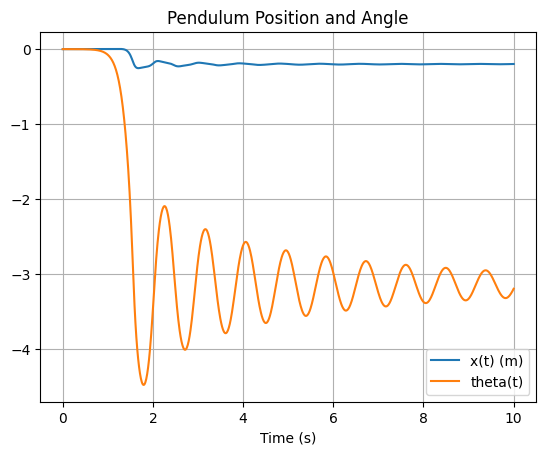

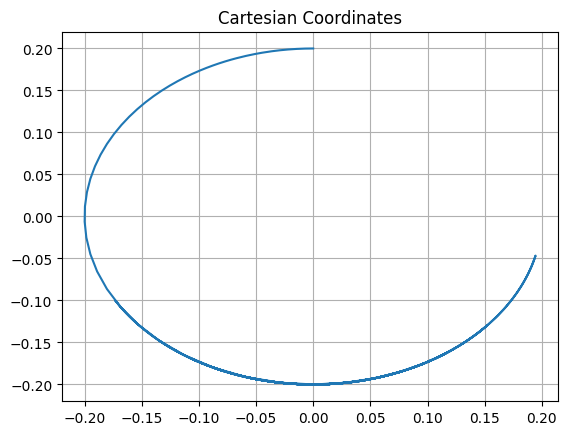

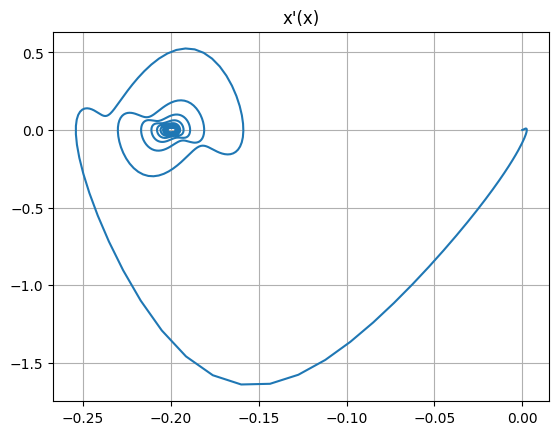

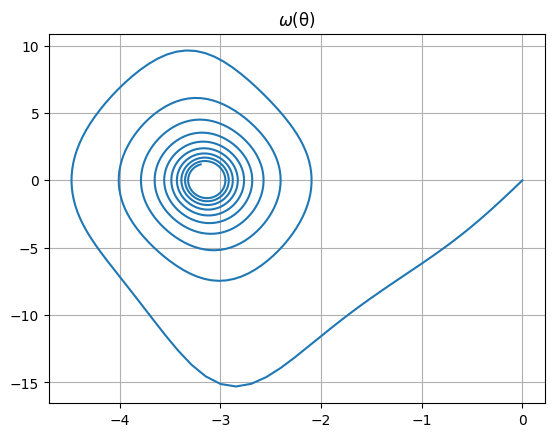

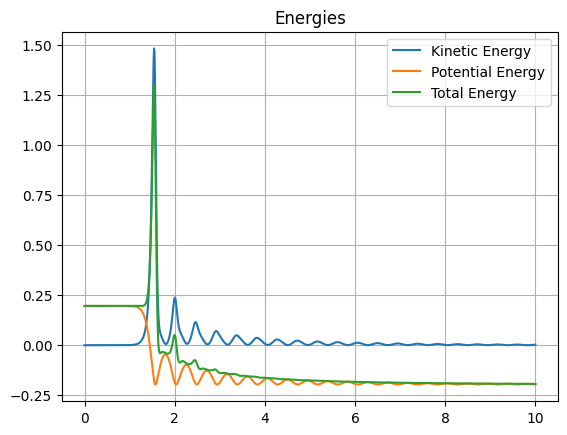

In [2]:
# Problem Constants:
M, m, l, g, mu = 1, 0.1, 0.2, 9.81, 10
u = rd.uniform(0, 0.01)
# Initial conditions:
x0, vx0, theta0, vtheta0 = 0., 0., 0., 0.
r = np.array([x0, theta0, vx0, vtheta0], float)

def F(r, t):
    # Function with the differential equations:
    x = r[0]
    theta = r[1]
    vx = r[2]
    vtheta = r[3]
    
    def lambdat(theta):
        return 1 / (l * (M + m * np.sin(theta)**2))
    
    fx = vx
    ftheta = vtheta
    fvx = lambdat(theta) * l * (m * g * np.sin(theta) * (l * vtheta**2 - np.cos(theta)) - mu * vx + u)
    fvtheta = lambdat(theta) * ((m + M) * g * np.sin(theta) - np.cos(theta) * (m * g * l * vtheta**2 * np.sin(theta) - mu * vx + u))
    return np.array([fx, ftheta, fvx, fvtheta])

def inverted_pendulum(F, a, b, N, r):
    h = (b - a) / N
    tp = np.linspace(a, b, N)
    xp = []
    thetap = []
    vxp = []
    vthetap = []
    r = np.array(r, float)
    
    # Cartesian coordinates:
    xc = []
    yc = []
    
    # Energies:
    T = []
    V = []
    E = []
    
    for t in tp:
        xp.append(r[0])
        thetap.append(r[1])
        vxp.append(r[2])
        vthetap.append(r[3])
        
        # Cartesian coordinates:
        xc.append(l * np.sin(r[1]))
        yc.append(l * np.cos(r[1]))
        
        # Energies:
        kinetic = (M * r[2]**2) / 2 + (m * (r[2]**2 + 2 * r[2] * r[3] * l * np.cos(r[1]) + (l * r[3])**2)) / 2
        pot = m * g * l * np.cos(r[1])
        T.append(kinetic)
        V.append(pot)
        E.append(kinetic + pot)
        
        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return tp, xp, thetap, vxp, vthetap, xc, yc, T, V, E

# Problem parameters:
t1, t2 = 0, 10
N = 1000
time, x, theta, xp, thetap, xc, yc, T, V, E = inverted_pendulum(F, t1, t2, N, r)

# Plot x(t) and theta(t):
plt.plot(time, x)
plt.plot(time, theta)
plt.xlabel("Time (s)")
plt.legend(["x(t) (m)", "theta(t)"])
plt.grid()
plt.title("Pendulum Position and Angle")
plt.show()

# Plot Cartesian coordinates:
plt.plot(xc, yc)
plt.title("Cartesian Coordinates")
plt.grid()
plt.show()

# Plot phase spaces:
plt.plot(x, xp)
plt.grid()
plt.title("x'(x)")
plt.show()
plt.plot(theta, thetap)
plt.title("$\omega$(θ)")
plt.grid()
plt.show()

# Plot energies as a function of time:
plt.plot(time, T)
plt.plot(time, V)
plt.plot(time, E)
plt.title("Energies")
plt.legend(["Kinetic Energy", "Potential Energy", "Total Energy"])
plt.grid()
plt.show()
